## PROJETO AVALIATIVO - PIPELINE PREDITIVO

In [1]:
#Importação da base de dados
import pandas as pd

df_bruto = pd.read_csv("data/manutencao_preditiva.csv")

df_bruto.head()


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


### FASE 1 - ANÁLISE EXPLORATÓRIA DOS DADOS

In [2]:
variaveis_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

In [3]:
from src.analysis import inspecionar_dados
inspecionar_dados(df_bruto, colunas_numericas=variaveis_numericas)

Dimensões do dataset: 10000 linhas x 14 colunas

Tipos de dados:
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Resumo estatístico (colunas numéricas):
       temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
count       9500.000000             9500.000000             9500.000000   
mean         300.002158              310.000895             1539.245263   
std            2.001689                1.486432              180.273589   
min          295.300000              305.700000             1168.000000   
25%          29

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min
count,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000
mean,300.002158,310.000895,1539.245263,39.974168,107.951000
std,2.001689,1.486432,180.273589,9.995453,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.100000,53.000000
50%,300.100000,310.100000,1504.000000,40.100000,108.000000
75%,301.500000,311.100000,1613.000000,46.700000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


## Geração de gráficos analíticos
Gráfico 1 - Histograma das variáveis preditores

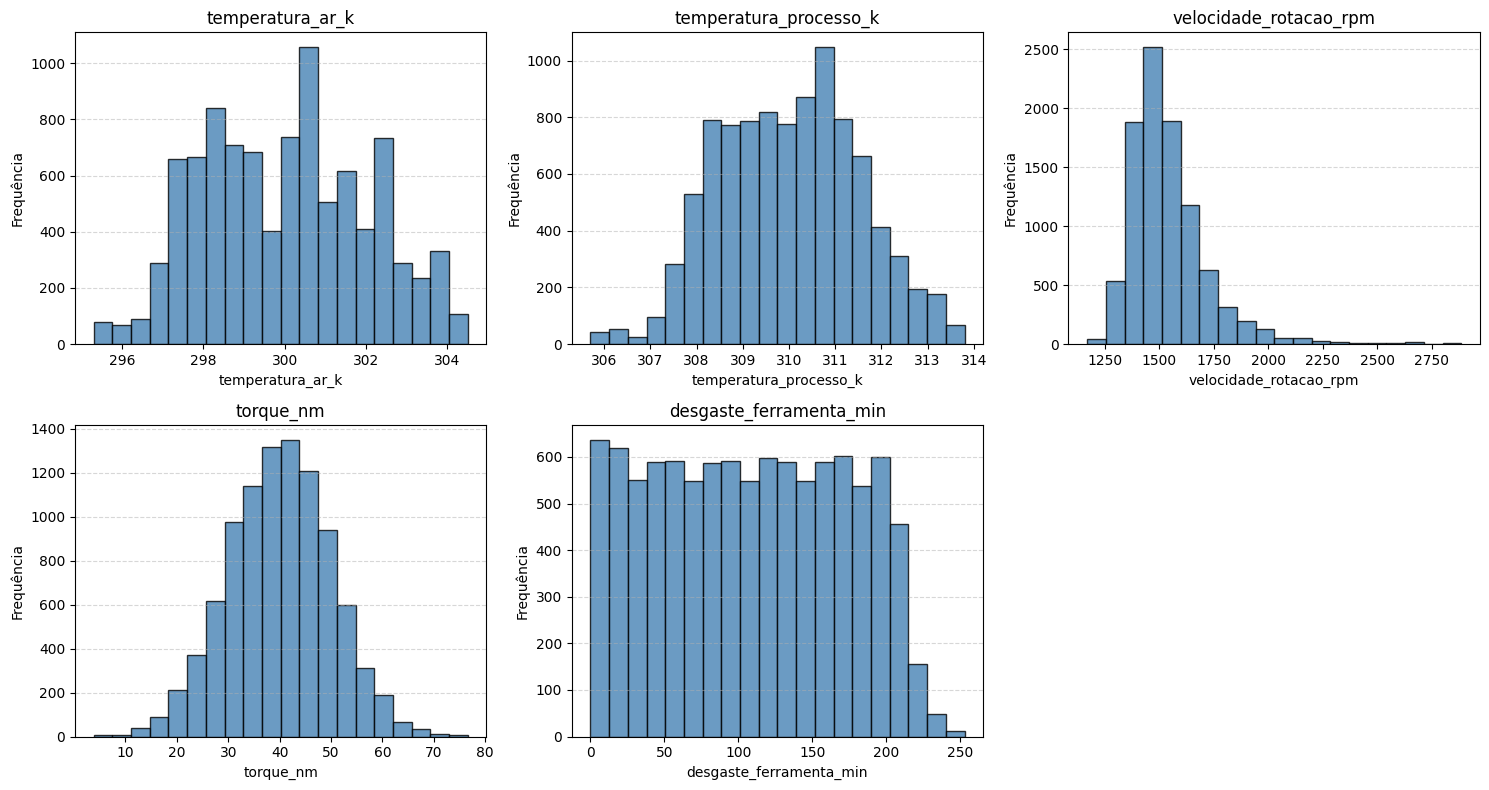

In [4]:
from src.visualization import gerar_histogramas
gerar_histogramas(df_bruto, variaveis_numericas)

Gráfico 2 - Gráfico de barras - taxa de desbalanceamento da variável alvo

c:\Users\eduarda.echer\pipeline-preditivo\src\visualization.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette=cores)
c:\Users\eduarda.echer\pipeline-preditivo\src\visualization.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


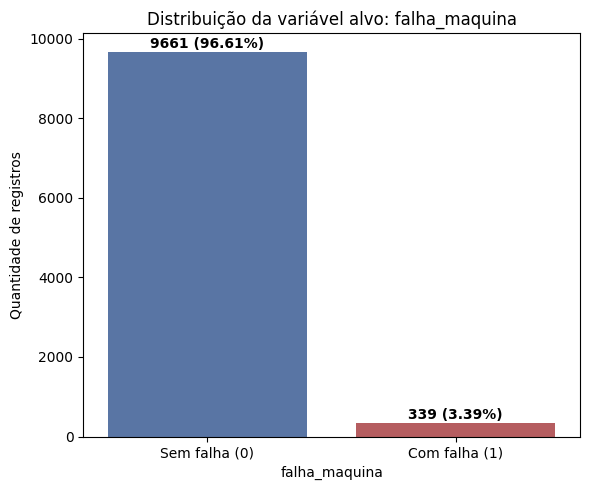

falha_maquina
0    9661
1     339
Name: count, dtype: int64
falha_maquina
0    96.61
1     3.39
Name: proportion, dtype: float64


In [5]:
from src.visualization import gerar_grafico_distribuicao_alvo

gerar_grafico_distribuicao_alvo(
    df_bruto, 
    coluna_alvo='falha_maquina', 
    labels=['Sem falha (0)', 'Com falha (1)']
)

Gráfico 3 - Mapa de calor - correlação de Pearson entre variáveis

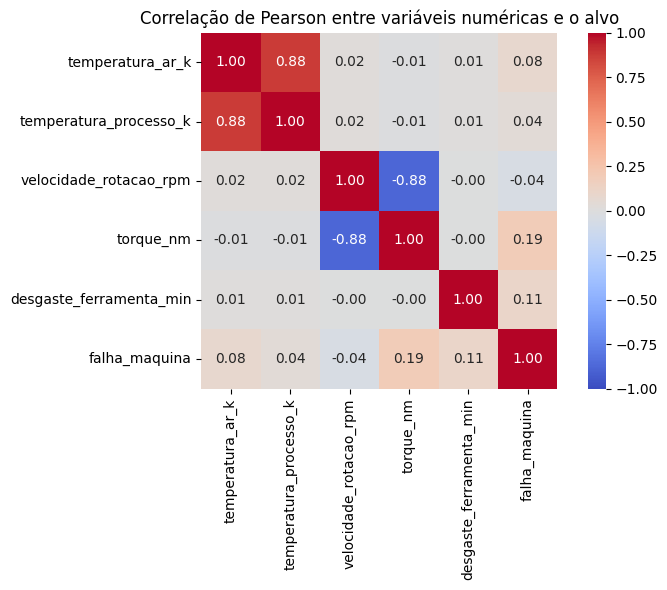

In [6]:
from src.visualization import gerar_heatmap_correlacao

colunas_correlacao = variaveis_numericas + ['falha_maquina']

matriz_corr = gerar_heatmap_correlacao(
    df_bruto, 
    colunas=colunas_correlacao, 
    titulo="Correlação de Pearson entre variáveis numéricas e o alvo"
)

## Conclusões sobre a Análise Exploratória de Dados

- **Dimensões e tipos**: o dataset possui 10.000 registros e 14 colunas, sendo:
  - 5 variáveis numéricas consideradas relevantes para a modelagem (temperatura_ar_k, temperatura_processo_k, velocidade_rotacao_rpm, torque_nm, desgaste_ferramenta_min),
  - uma variável categórica (tipo do produto: L, M, H) e,
  - a variável alvo em formato binário falha_maquina.
  - As colunas udi e id_produto são colunas identificadoras e serão descartadas da modelagem. 
  - As colunas falha_twf, falha_hdf, falha_pwf, falha_osf e falha_rnf indicam o tipo específico de falha e serão excluídas das features, pois não tem utilidade para essa análise.
- **Resumo estatístico**: as variáveis de temperatura têm baixa dispersão (desvio-padrão ~2K), enquanto torque_nm e velocidade_rotacao_rpm apresentam maior variabilidade. O desgaste_ferramenta_min varia de 0 a aproximadamente 253 minutos, sugerindo diferentes estágios de vida útil da ferramenta no momento da medição.
- **Histogramas**: temperatura_ar_k, temperatura_processo_k, torque_nm e desgaste_ferramenta_min seguem distribuições próximas da normal (simétricas). Já velocidade_rotacao_rpm apresenta assimetria à direita, o que já indica presença de outliers e reforça a necessidade de tratamento na Fase 2 e de escalonamento (StandardScaler) antes de usar modelos sensíveis à escala, como o KNN.
- **Desbalanceamento do alvo**: apenas aproximadamente 3,4% dos registros (339 de 10.000) representam falha de máquina. Esse forte desbalanceamento indica que uma acurácia simples pode ser enganosa. Isso justifica a aplicação de reamostragem (SMOTE) exclusivamente no conjunto de treino na Fase 4, para evitar que o modelo ignore a classe minoritária.
- **Correlação de Pearson**: torque_nm e velocidade_rotacao_rpm apresentam correlação negativa forte entre si (fisicamente esperado, já que potência é aproximadamente constante). Em relação ao alvo, torque_nm e desgaste_ferramenta_min mostram as correlações lineares mais relevantes com falha_maquina, embora nenhuma variável isolada explique a falha sozinha, podendo sugerir que a relação é não linear, favorecendo modelos mais complexos (como a Árvore de Decisão) ou métodos baseados em distância (KNN).

Esses padrões direcionam a estratégia de modelagem: (1) tratar outliers e nulos antes de treinar; (2) criar uma variável combinada (potencia) que capture a relação física entre torque e rotação; (3) balancear apenas o treino; (4) escalonar variáveis apenas para o KNN; e (5) comparar KNN e Árvore de Decisão controlando o overfitting via n_neighbors e max_depth.

### FASE 2 - LIMPEZA E TRATAMENTO DOS DADOS

Exclusão de linhas duplicadas

In [7]:
from src.cleaning import remover_duplicados

df_tratado = remover_duplicados(df_bruto)

Linhas duplicadas encontradas: 0
Dimensões após remoção de duplicados: (10000, 14)


Identificação de dados ausentes

In [8]:
from src.cleaning import identificar_ausentes

resumo_ausentes = identificar_ausentes(df_tratado)
resumo_ausentes

Valores ausentes por coluna:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64



,ausentes,percentual (%)
udi,0,0.0
id_produto,0,0.0
tipo,0,0.0
temperatura_ar_k,500,5.0
temperatura_processo_k,500,5.0
velocidade_rotacao_rpm,500,5.0
torque_nm,500,5.0
desgaste_ferramenta_min,0,0.0
falha_maquina,0,0.0
falha_twf,0,0.0


Usando como base a análise exploratória realizada na Fase 1 optou-se por tomar as seguintes decisões:
- Para as colunas temperatura_ar_k e temperatura_processo_k: será adotada a média para os valore nulos, pois o desvio padrão de ambas as colunas é baixo.
- Para as colunas velocidade_rotacao_rpm e torque_nm: será adotada a mediana para os valores nulos, pois o desvio padrão é mais alto, o que torna a mediana mais adequada tendo em vista a chance da presença de outliers.

In [9]:
colunas_media = ['temperatura_ar_k', 'temperatura_processo_k']
colunas_mediana = ['velocidade_rotacao_rpm', 'torque_nm']

from src.cleaning import imputar_media
from src.cleaning import imputar_mediana

df_tratado = imputar_media(df_tratado, colunas=colunas_media)
df_tratado = imputar_mediana(df_tratado, colunas=colunas_mediana)

temperatura_ar_k: nulos preenchidos com a média (300.00)
temperatura_processo_k: nulos preenchidos com a média (310.00)
velocidade_rotacao_rpm: nulos preenchidos com a mediana (1504.00)
torque_nm: nulos preenchidos com a mediana (40.10)


Gerando gráficos Boxplot para confirmar a presença de outliars no dataframe.

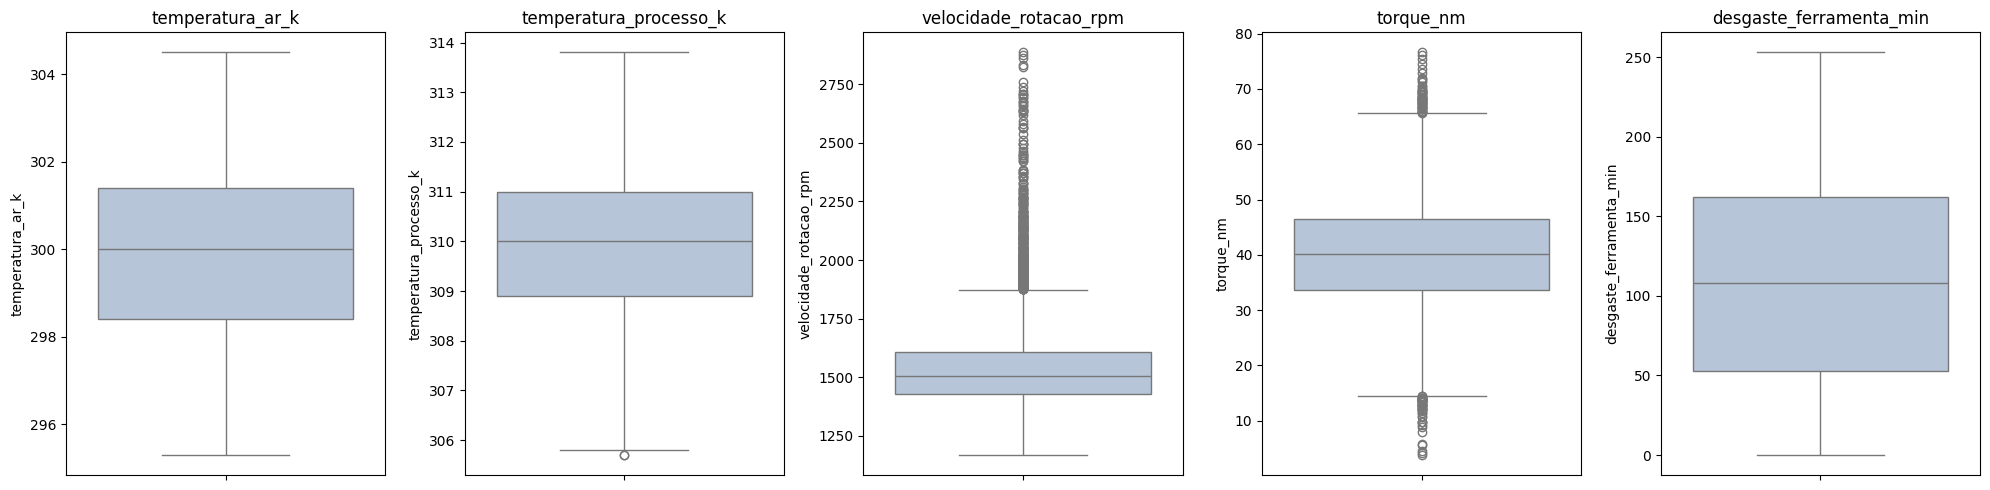

In [10]:
from src.visualization import gerar_boxplots

gerar_boxplots(df_tratado, colunas=variaveis_numericas)

**Observação sobre outliers:** os boxplots de velocidade_rotacao_rpm e de torque_nm mostram pontos fora dos limites, confirmando a presença de outliers e a assimetria detectada no histograma da Fase 1. Optou-se por não remover esses outliers, pois, no contexto de manutenção preditiva, valores extremos de rotação/torque podem ser justamente os sinais que precedem uma falha e removê-los poderia eliminar informação relevante para o modelo.

### FASE 3 - FEATURE ENGINEERING

Será criada a nova coluna "Potência" sendo essa o resultado do produto entre velocidade_rotacao_rpm e torque_nm.
A função está preparada para identificar se existem dados nulos nas colunas de origem.

In [11]:
from src.feature import criar_feature_produto

df_features = criar_feature_produto(
    df_tratado,
    coluna_a='velocidade_rotacao_rpm',
    coluna_b='torque_nm',
    nome_nova_coluna='potencia'
)

variaveis_numericas = variaveis_numericas + ['potencia']

df_features[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


### FASE 4 - DIVISÃO E BALANCEAMENTO DOS DADOS

Antes de separar X e y, serão descartadas algumas colunas que não tem relevância para o modelo, sendo:
- udi e id_produto: colunas identificadoras;
- falha_twf, falha_hdf, falha_pwf, falha_osf, falha_rnf: indicam o tipo específico de falha e não devem ser usados pelo modelo pois são informações que não estariam disponíveis no momento da predição.
- A variável categórica tipo (L/M/H) foi convertida em números (one-hot encoding).

In [12]:
from src.training import preparar_x_y

colunas_vazamento = ['falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
colunas_id = ['udi', 'id_produto']

X, y = preparar_x_y(
    df_features,
    colunas_remover=colunas_vazamento + colunas_id,
    coluna_alvo='falha_maquina',
    colunas_categoricas=['tipo']
)

Colunas de X: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia', 'tipo_L', 'tipo_M']
Distribuição de y:
falha_maquina
0    9661
1     339
Name: count, dtype: int64


DIVIDINDO OS DADOS DE TREINO/TESTE

In [13]:
from src.training import dividir_treino_teste

X_train, X_test, y_train, y_test = dividir_treino_teste(X, y, test_size=0.2, random_state=42)

Treino: 8000 amostras | Teste: 2000 amostras
Proporção da classe positiva no treino: 3.39 %
Proporção da classe positiva no teste:  3.4 %


APLICANDO TÉCNICA DE REAMOSTRAGEM (SMOTE)

Como a base de dados não é muito grande, optou-se por utilizar a técnica SMOTE

O SMOTE é uma técnica utilizada para balancear conjuntos de dados desbalanceados, criando novas amostras sintéticas da classe minoritária. 
Devido a quantidade de dados sem falha ser muito maior que a quantidade de vezes que a máquina falhou, é necessário realizar esse balanceamento para que o modelo receba a mesma quantidade de exemplos de cada classe.

In [14]:
from src.training import aplicar_smote

X_train_bal, y_train_bal = aplicar_smote(X_train, y_train, random_state=42)

Distribuição do treino ANTES do SMOTE:
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição do treino DEPOIS do SMOTE:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


c:\Users\eduarda.echer\pipeline-preditivo\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


### FASE 5 - ESCALONAMENTO DE VARIÁVEIS (STANDARD SCALER)

O **KNN** é um algoritmo baseado em distância: variáveis com escalas maiores (ex: velocidade_rotacao_rpm, na casa das centenas/milhares) dominariam o cálculo da distância em relação a variáveis menores (ex: temperatura_ar_k, na casa das centenas), distorcendo os vizinhos mais próximos. 
Dessa forma, torna-se necessário (apenas para o KNN) escalonarmos as variáveis contínuas.

Já a **Árvore de Decisão** toma decisões comparando os valores de cada variável separadamente (por exemplo, verificando se um valor é maior ou menor que um determinado limite). Como ela não utiliza distâncias entre os registros, não é afetada pela escala das variáveis. Por isso, pode ser treinada com os dados originais, sem a necessidade de aplicar o StandardScaler.

In [15]:
from src.scaler import escalonar_para_knn

colunas_continuas = ['temperatura_ar_k', 'temperatura_processo_k',
                     'velocidade_rotacao_rpm', 'torque_nm',
                     'desgaste_ferramenta_min', 'potencia']

X_train_knn, X_test_knn, scaler = escalonar_para_knn(X_train_bal, X_test, colunas_continuas)

# Para a Árvore de Decisão, usamos os dados balanceados SEM escalonar
X_train_arvore = X_train_bal.copy()
X_test_arvore = X_test.copy()

print("KNN - exemplo de dados escalonados:")
print(X_train_knn[colunas_continuas].head(3))
print()
print("Árvore - dados originais (sem escalonamento):")
print(X_train_arvore[colunas_continuas].head(3))

KNN - exemplo de dados escalonados:
   temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0         -0.223599               -0.119453               -0.055385   
1         -1.820140               -1.428760               -0.413819   
2          0.307051                1.111498               -0.557193   

   torque_nm  desgaste_ferramenta_min  potencia  
0  -0.323475                -1.048131 -0.277696  
1   0.121609                 0.127521  0.033353  
2   0.065091                 0.202884 -0.171688  

Árvore - dados originais (sem escalonamento):
   temperatura_ar_k  temperatura_processo_k  velocidade_rotacao_rpm  \
0        300.002158              310.000895                  1504.0   
1        297.000000              308.300000                  1399.0   
2        301.000000              311.600000                  1357.0   

   torque_nm  desgaste_ferramenta_min  potencia  
0       40.1                       54   60310.4  
1       46.4                      132   64913.6